<a href="https://colab.research.google.com/github/MALISMF/Intelligent-Agents-Graph-Networks-and-Other-Practical-Machine-Learning-Tasks/blob/main/gan-nums/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорты и конфиг

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from tqdm import tqdm

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

latent_dim = 100
batch_size = 128
learning_rate = 0.0002
num_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Pad(2)
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


# Generator + Discriminator

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, feature_maps=64, image_size=32):
        super().__init__()
        num_layers = int(round(math.log2(image_size))) - 2
        layers = []
        current_size = 4
        current_channels = feature_maps * (2 ** (num_layers - 1))
        layers.append(nn.Linear(latent_dim, current_channels * current_size * current_size))
        layers.append(nn.Unflatten(1, (current_channels, current_size, current_size)))
        for i in range(num_layers):
            in_channels = current_channels
            out_channels = current_channels // 2 if i < num_layers - 1 else 1
            layers.append(nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4,
                stride=2, padding=1, bias=False))
            if i < num_layers - 1:
                layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU(inplace=True))
            else:
                layers.append(nn.Tanh())
            current_channels = out_channels
        self.model = nn.Sequential(*layers)

    def forward(self, z):
        return self.model(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, feature_maps=64, image_size=32):
        super().__init__()
        num_layers = int(round(math.log2(image_size))) - 2
        layers = []
        current_channels = 1
        for i in range(num_layers + 1):
            out_channels = feature_maps * (2 ** i) if i < num_layers else 1
            layers.append(nn.Conv2d(
                current_channels, out_channels, kernel_size=4,
                stride=2, padding=1, bias=False))
            if i > 0 and i < num_layers:
                layers.append(nn.BatchNorm2d(out_channels))
            if i < num_layers:
                layers.append(nn.LeakyReLU(0.2, inplace=True))
            current_channels = out_channels
        layers.append(nn.Flatten())
        layers.append(nn.Linear(4, 1))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x).view(-1)

# Инициализация

In [ ]:
generator     = Generator(latent_dim=latent_dim, feature_maps=64, image_size=32).to(device)
discriminator = Discriminator(feature_maps=64, image_size=32).to(device)

optimizer_G = optim.Adam(generator.parameters(),     lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
criterion   = nn.BCELoss()
fixed_noise = torch.randn(64, latent_dim, device=device)

# Обучение GAN

In [ ]:
os.makedirs("dgan_results", exist_ok=True)
losses   = []
saved_z      = []
saved_images = []

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        batch_size = real_images.size(0)
        real_images = real_images.view(batch_size, 1, 32, 32).to(device)
        real_labels = torch.full((batch_size,), 0.9, dtype=torch.float, device=device)
        fake_labels = torch.zeros(batch_size, dtype=torch.float, device=device)

        optimizer_D.zero_grad()
        outputs      = discriminator(real_images)
        d_loss_real  = criterion(outputs, real_labels)
        z            = torch.randn(batch_size, latent_dim, device=device)
        fake_images  = generator(z)
        outputs      = discriminator(fake_images.detach())
        d_loss_fake  = criterion(outputs, fake_labels)
        d_loss       = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        z           = torch.randn(batch_size, latent_dim, device=device)
        fake_images = generator(z)
        outputs     = discriminator(fake_images)
        g_loss      = criterion(outputs, real_labels)
        g_loss.backward()
        optimizer_G.step()

    losses.append([epoch, d_loss.item(), g_loss.item()])
    print(f"Epoch {epoch+1}/{num_epochs}  Loss D: {d_loss.item():.4f}  Loss G: {g_loss.item():.4f}")

    with torch.no_grad():
        fake    = generator(fixed_noise).view(-1, 1, 32, 32)
        img_grid = torchvision.utils.make_grid(fake, normalize=True, value_range=(-1, 1), nrow=8)
        img_grid = img_grid.cpu().numpy().transpose(1, 2, 0)
        img_grid = (img_grid * 0.5 + 0.5)
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.imshow(img_grid)
        plt.savefig(f"dgan_results/epoch_{epoch+1:03d}.png", bbox_inches='tight', pad_inches=0)
        plt.close()

# Сохраняем 100 z и картинок после обучения
generator.eval()
with torch.no_grad():
    for i in range(100):
        z     = torch.randn(1, latent_dim, device=device)
        image = generator(z)
        saved_z.append(z.cpu())
        saved_images.append(image.cpu())

Epoch 1/50: 100%|██████████| 469/469 [00:21<00:00, 22.30it/s]


Epoch 1/50  Loss D: 0.8885  Loss G: 2.5332


Epoch 2/50: 100%|██████████| 469/469 [00:18<00:00, 24.83it/s]


Epoch 2/50  Loss D: 0.6003  Loss G: 1.3615


Epoch 3/50: 100%|██████████| 469/469 [00:18<00:00, 25.58it/s]


...

Epoch 48/50  Loss D: 0.3866  Loss G: 2.8489


Epoch 49/50: 100%|██████████| 469/469 [00:18<00:00, 25.77it/s]


Epoch 49/50  Loss D: 0.5275  Loss G: 2.3756


Epoch 50/50: 100%|██████████| 469/469 [00:19<00:00, 24.66it/s]


Epoch 50/50  Loss D: 0.4265  Loss G: 3.3965


# Визуализация сгенерированных изображений

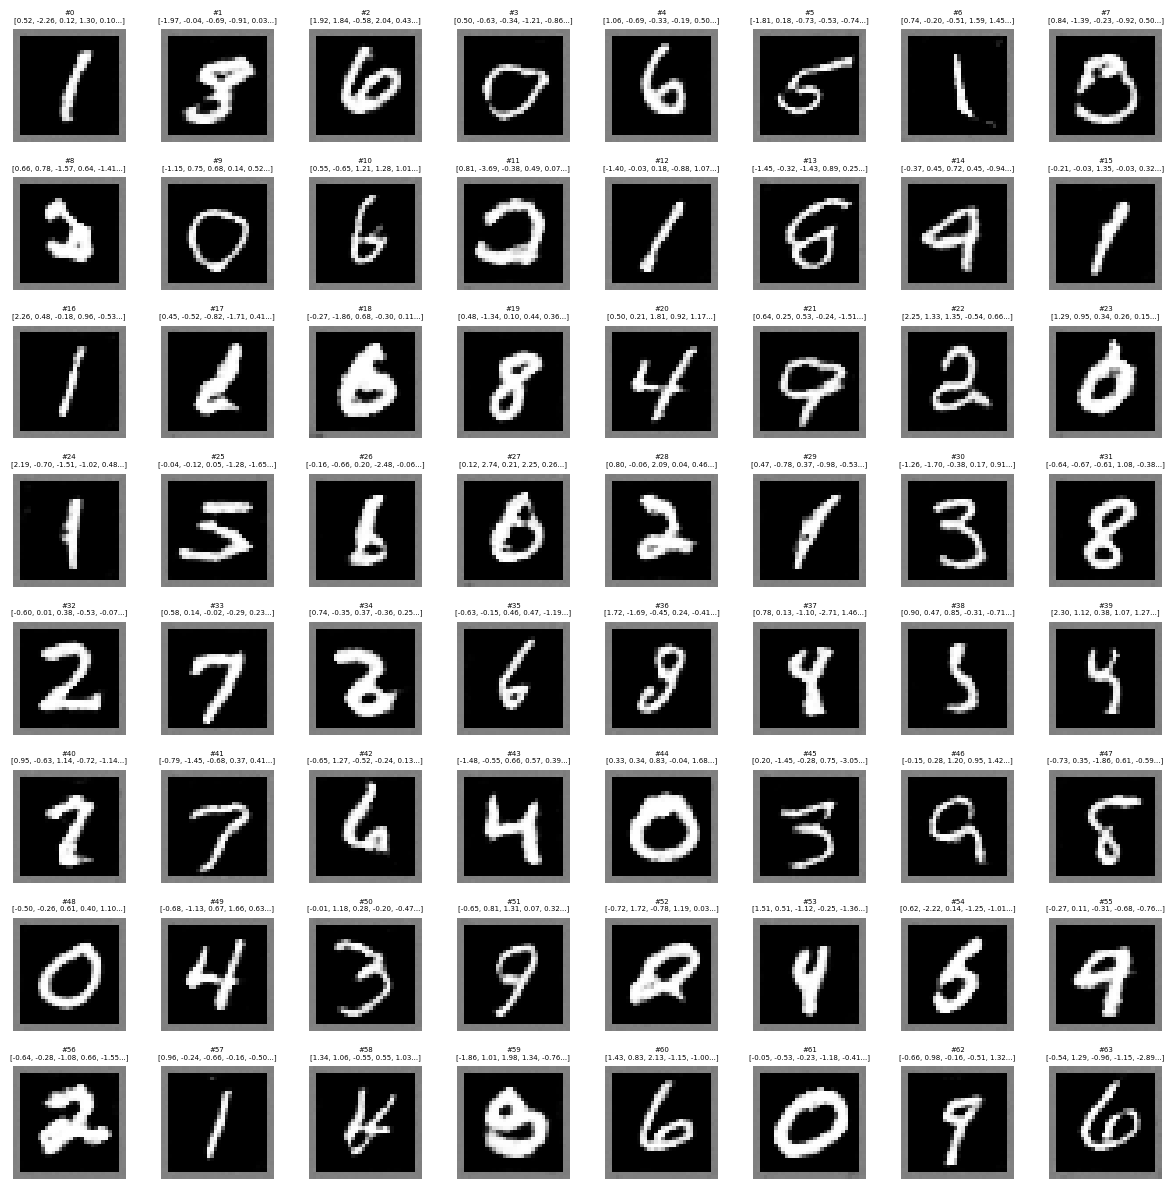

In [ ]:
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img    = saved_images[i].cpu().detach().numpy()
    img    = (img * 0.5 + 0.5).squeeze()
    z_vals = saved_z[i].squeeze().numpy()[:5]
    z_str  = '[' + ', '.join([f'{v:.2f}' for v in z_vals]) + '...]'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'#{i}\n{z_str}', fontsize=5)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Классификатор MNIST

In [ ]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

train_data = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=256)

classifier    = MNISTClassifier().to(device)
optimizer_cls = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion_cls = nn.CrossEntropyLoss()

for epoch in range(5):
    classifier.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_cls.zero_grad()
        loss = criterion_cls(classifier(images), labels)
        loss.backward()
        optimizer_cls.step()

    classifier.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            correct += (classifier(images).argmax(dim=1) == labels).sum().item()
    print(f"Epoch {epoch+1}/5  accuracy: {correct / len(test_data):.4f}")

Epoch 1/5  accuracy: 0.9816
Epoch 2/5  accuracy: 0.9815
Epoch 3/5  accuracy: 0.9867
Epoch 4/5  accuracy: 0.9882
Epoch 5/5  accuracy: 0.9881


# Сбор z по классам и вычисление dz

In [ ]:
# Пункт 1: Генерируем 2000 изображений, классификатор раскладывает z по цифрам
z_by_class = {i: [] for i in range(10)}

generator.eval()
classifier.eval()

with torch.no_grad():
    for _ in tqdm(range(2000), desc="Сбор z по классам"):
        z     = torch.randn(1, latent_dim, device=device)
        image = generator(z)
        label = classifier(image).argmax(dim=1).item()
        z_by_class[label].append(z.cpu().squeeze())

for digit, zs in z_by_class.items():
    print(f"Цифра {digit}: {len(zs)} примеров")

Сбор z по классам: 100%|██████████| 2000/2000 [00:01<00:00, 1152.61it/s]

Цифра 0: 244 примеров
Цифра 1: 228 примеров
Цифра 2: 148 примеров
Цифра 3: 197 примеров
Цифра 4: 168 примеров
Цифра 5: 170 примеров
Цифра 6: 168 примеров
Цифра 7: 210 примеров
Цифра 8: 212 примеров
Цифра 9: 255 примеров


In [ ]:
# Пункт 2: Считаем dz = mean(z[N+1]) - mean(z[N])
N  = 3
N1 = 4

z_N  = torch.stack(z_by_class[N]).mean(dim=0)
z_N1 = torch.stack(z_by_class[N1]).mean(dim=0)
dz   = z_N1 - z_N

print(f"Примеров для цифры {N}:  {len(z_by_class[N])}")
print(f"Примеров для цифры {N1}: {len(z_by_class[N1])}")
print(f"dz первые 5 значений: {dz[:5].numpy()}")

Примеров для цифры 3:  197
Примеров для цифры 4: 168
dz первые 5 значений: [ 0.14070779  0.44405103 -0.154117    0.03263636  0.21546556]


# Генерация G(z) и G(z+dz)

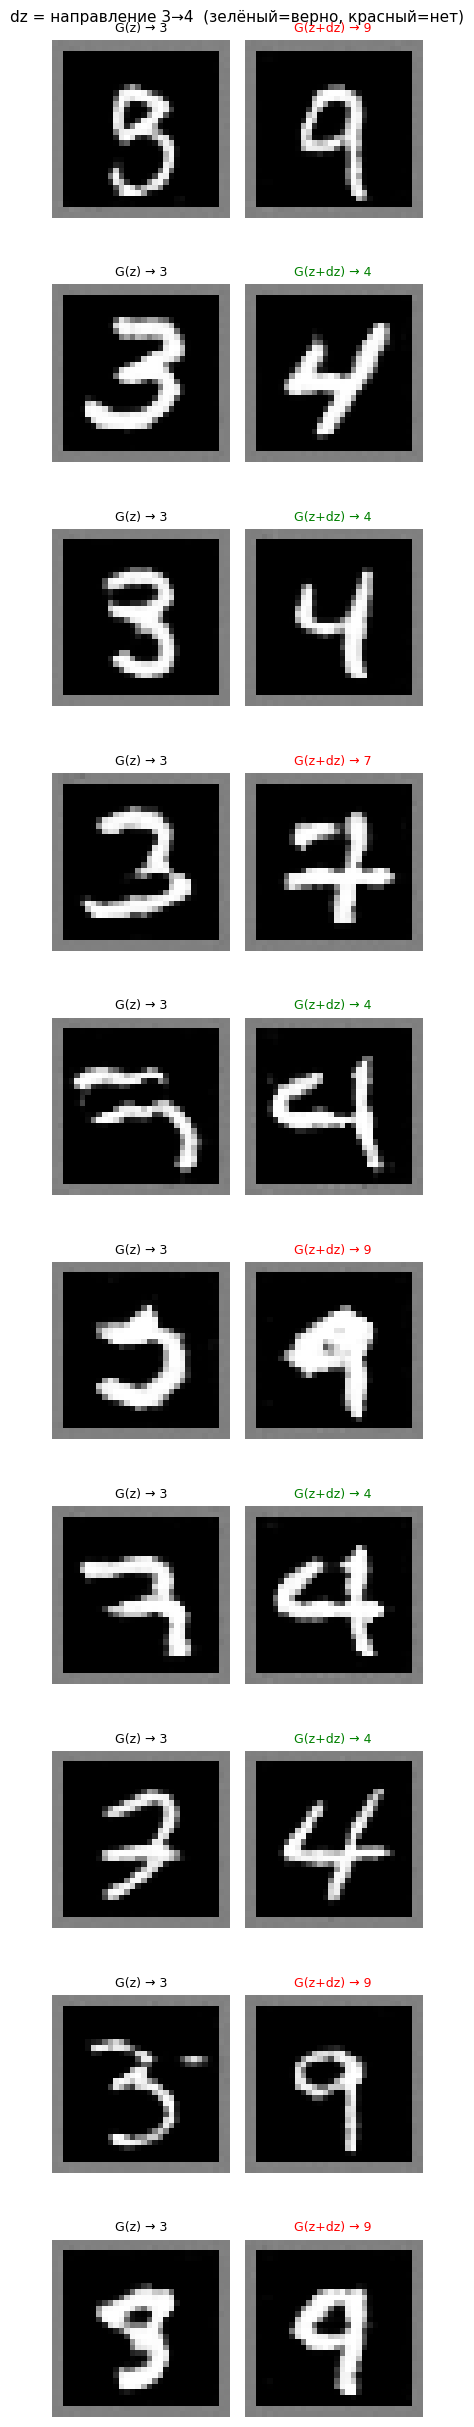

In [ ]:
# Пункт 3: Берём случайные z (новые, не из выборки) и показываем G(z) vs G(z+dz)
n_show = 10
found  = 0
fig, axes = plt.subplots(n_show, 2, figsize=(4, n_show * 2.5))

with torch.no_grad():
    while found < n_show:
        z_new      = torch.randn(1, latent_dim, device=device)
        img_orig   = generator(z_new)
        label_orig = classifier(img_orig).argmax(dim=1).item()

        if label_orig != N:  # пропускаем если не тройка
            continue

        img_shift   = generator(z_new + dz.to(device))
        label_shift = classifier(img_shift).argmax(dim=1).item()

        img1 = (img_orig.cpu().squeeze().numpy()  * 0.5 + 0.5)
        img2 = (img_shift.cpu().squeeze().numpy() * 0.5 + 0.5)

        color = 'green' if label_shift == N1 else 'red'

        axes[found, 0].imshow(img1, cmap='gray')
        axes[found, 0].set_title(f'G(z) → {label_orig}', fontsize=9)
        axes[found, 0].axis('off')

        axes[found, 1].imshow(img2, cmap='gray')
        axes[found, 1].set_title(f'G(z+dz) → {label_shift}', fontsize=9, color=color)
        axes[found, 1].axis('off')

        found += 1

plt.suptitle(f'dz = направление {N}→{N1}  (зелёный=верно, красный=нет)', fontsize=11)
plt.tight_layout()
plt.show()

# Проверка гипотезы z'→[M], z'+dz→[M+1]

In [ ]:
# Пункт 4а: Проверка для пары N→N+1 на новых случайных z
generator.eval()
classifier.eval()

n_tests = 200
success = 0
total_n = 0  # сколько раз исходный z дал цифру N

with torch.no_grad():
    for _ in range(n_tests):
        z_new      = torch.randn(1, latent_dim, device=device)
        img        = generator(z_new)
        label      = classifier(img).argmax(dim=1).item()

        z_shifted  = z_new + dz.to(device)
        img_shift  = generator(z_shifted)
        label_shift = classifier(img_shift).argmax(dim=1).item()

        if label == N:
            total_n += 1
            if label_shift == N1:
                success += 1

print(f"Из {n_tests} случайных z:")
print(f"  Исходный z дал цифру {N}: {total_n} раз")
print(f"  Из них z+dz дало цифру {N1}: {success} раз ({success/total_n*100:.0f}%)" if total_n > 0 else "  Нет примеров")

Из 200 случайных z:
  Исходный z дал цифру 3: 21 раз
  Из них z+dz дало цифру 4: 15 раз (71%)


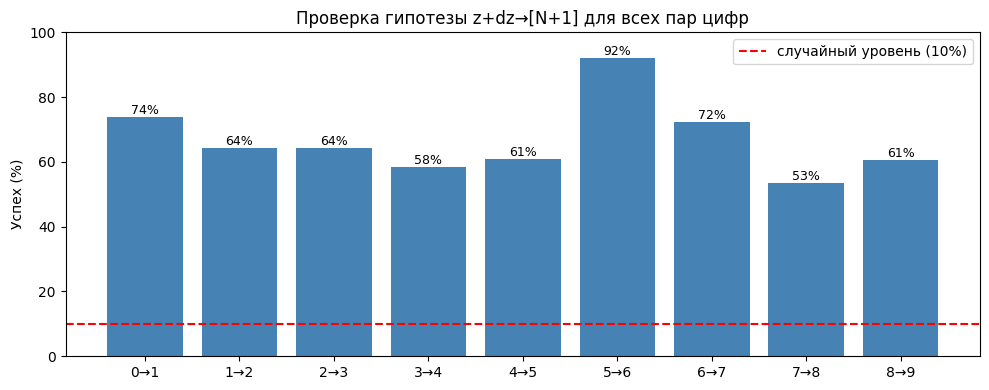


Результаты:
  ✓ 0→1: 45/61 (74%)
  ✓ 1→2: 34/53 (64%)
  ✓ 2→3: 27/42 (64%)
  ✓ 3→4: 31/53 (58%)
  ✓ 4→5: 25/41 (61%)
  ✓ 5→6: 23/25 (92%)
  ✓ 6→7: 39/54 (72%)
  ✓ 7→8: 23/43 (53%)
  ✓ 8→9: 23/38 (61%)


In [ ]:
# Пункт 4б: Проверка гипотезы для всех пар цифр
pairs   = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(8,9)]
results = {}

generator.eval()
classifier.eval()

for (n, n1) in pairs:
    if len(z_by_class[n]) == 0 or len(z_by_class[n1]) == 0:
        results[(n, n1)] = (0, 0)
        continue

    dz_pair = torch.stack(z_by_class[n1]).mean(dim=0) - torch.stack(z_by_class[n]).mean(dim=0)

    success = 0
    total   = 0

    with torch.no_grad():
        for _ in range(500):
            z_new      = torch.randn(1, latent_dim, device=device)
            label      = classifier(generator(z_new)).argmax(dim=1).item()
            label_shift = classifier(generator(z_new + dz_pair.to(device))).argmax(dim=1).item()
            if label == n:
                total += 1
                if label_shift == n1:
                    success += 1

    results[(n, n1)] = (success, total)

# Визуализация
labels = [f'{n}→{n1}' for (n, n1) in pairs]
pcts   = [results[p][0]/results[p][1]*100 if results[p][1] > 0 else 0 for p in pairs]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, pcts, color='steelblue')
ax.axhline(y=10, color='red', linestyle='--', label='случайный уровень (10%)')
ax.set_ylabel('Успех (%)')
ax.set_title('Проверка гипотезы z+dz→[N+1] для всех пар цифр')
ax.legend()
ax.set_ylim(0, 100)

for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nРезультаты:")
for (n, n1), (s, t) in results.items():
    pct    = s/t*100 if t > 0 else 0
    status = "✓" if pct > 10 else "✗"
    print(f"  {status} {n}→{n1}: {s}/{t} ({pct:.0f}%)")

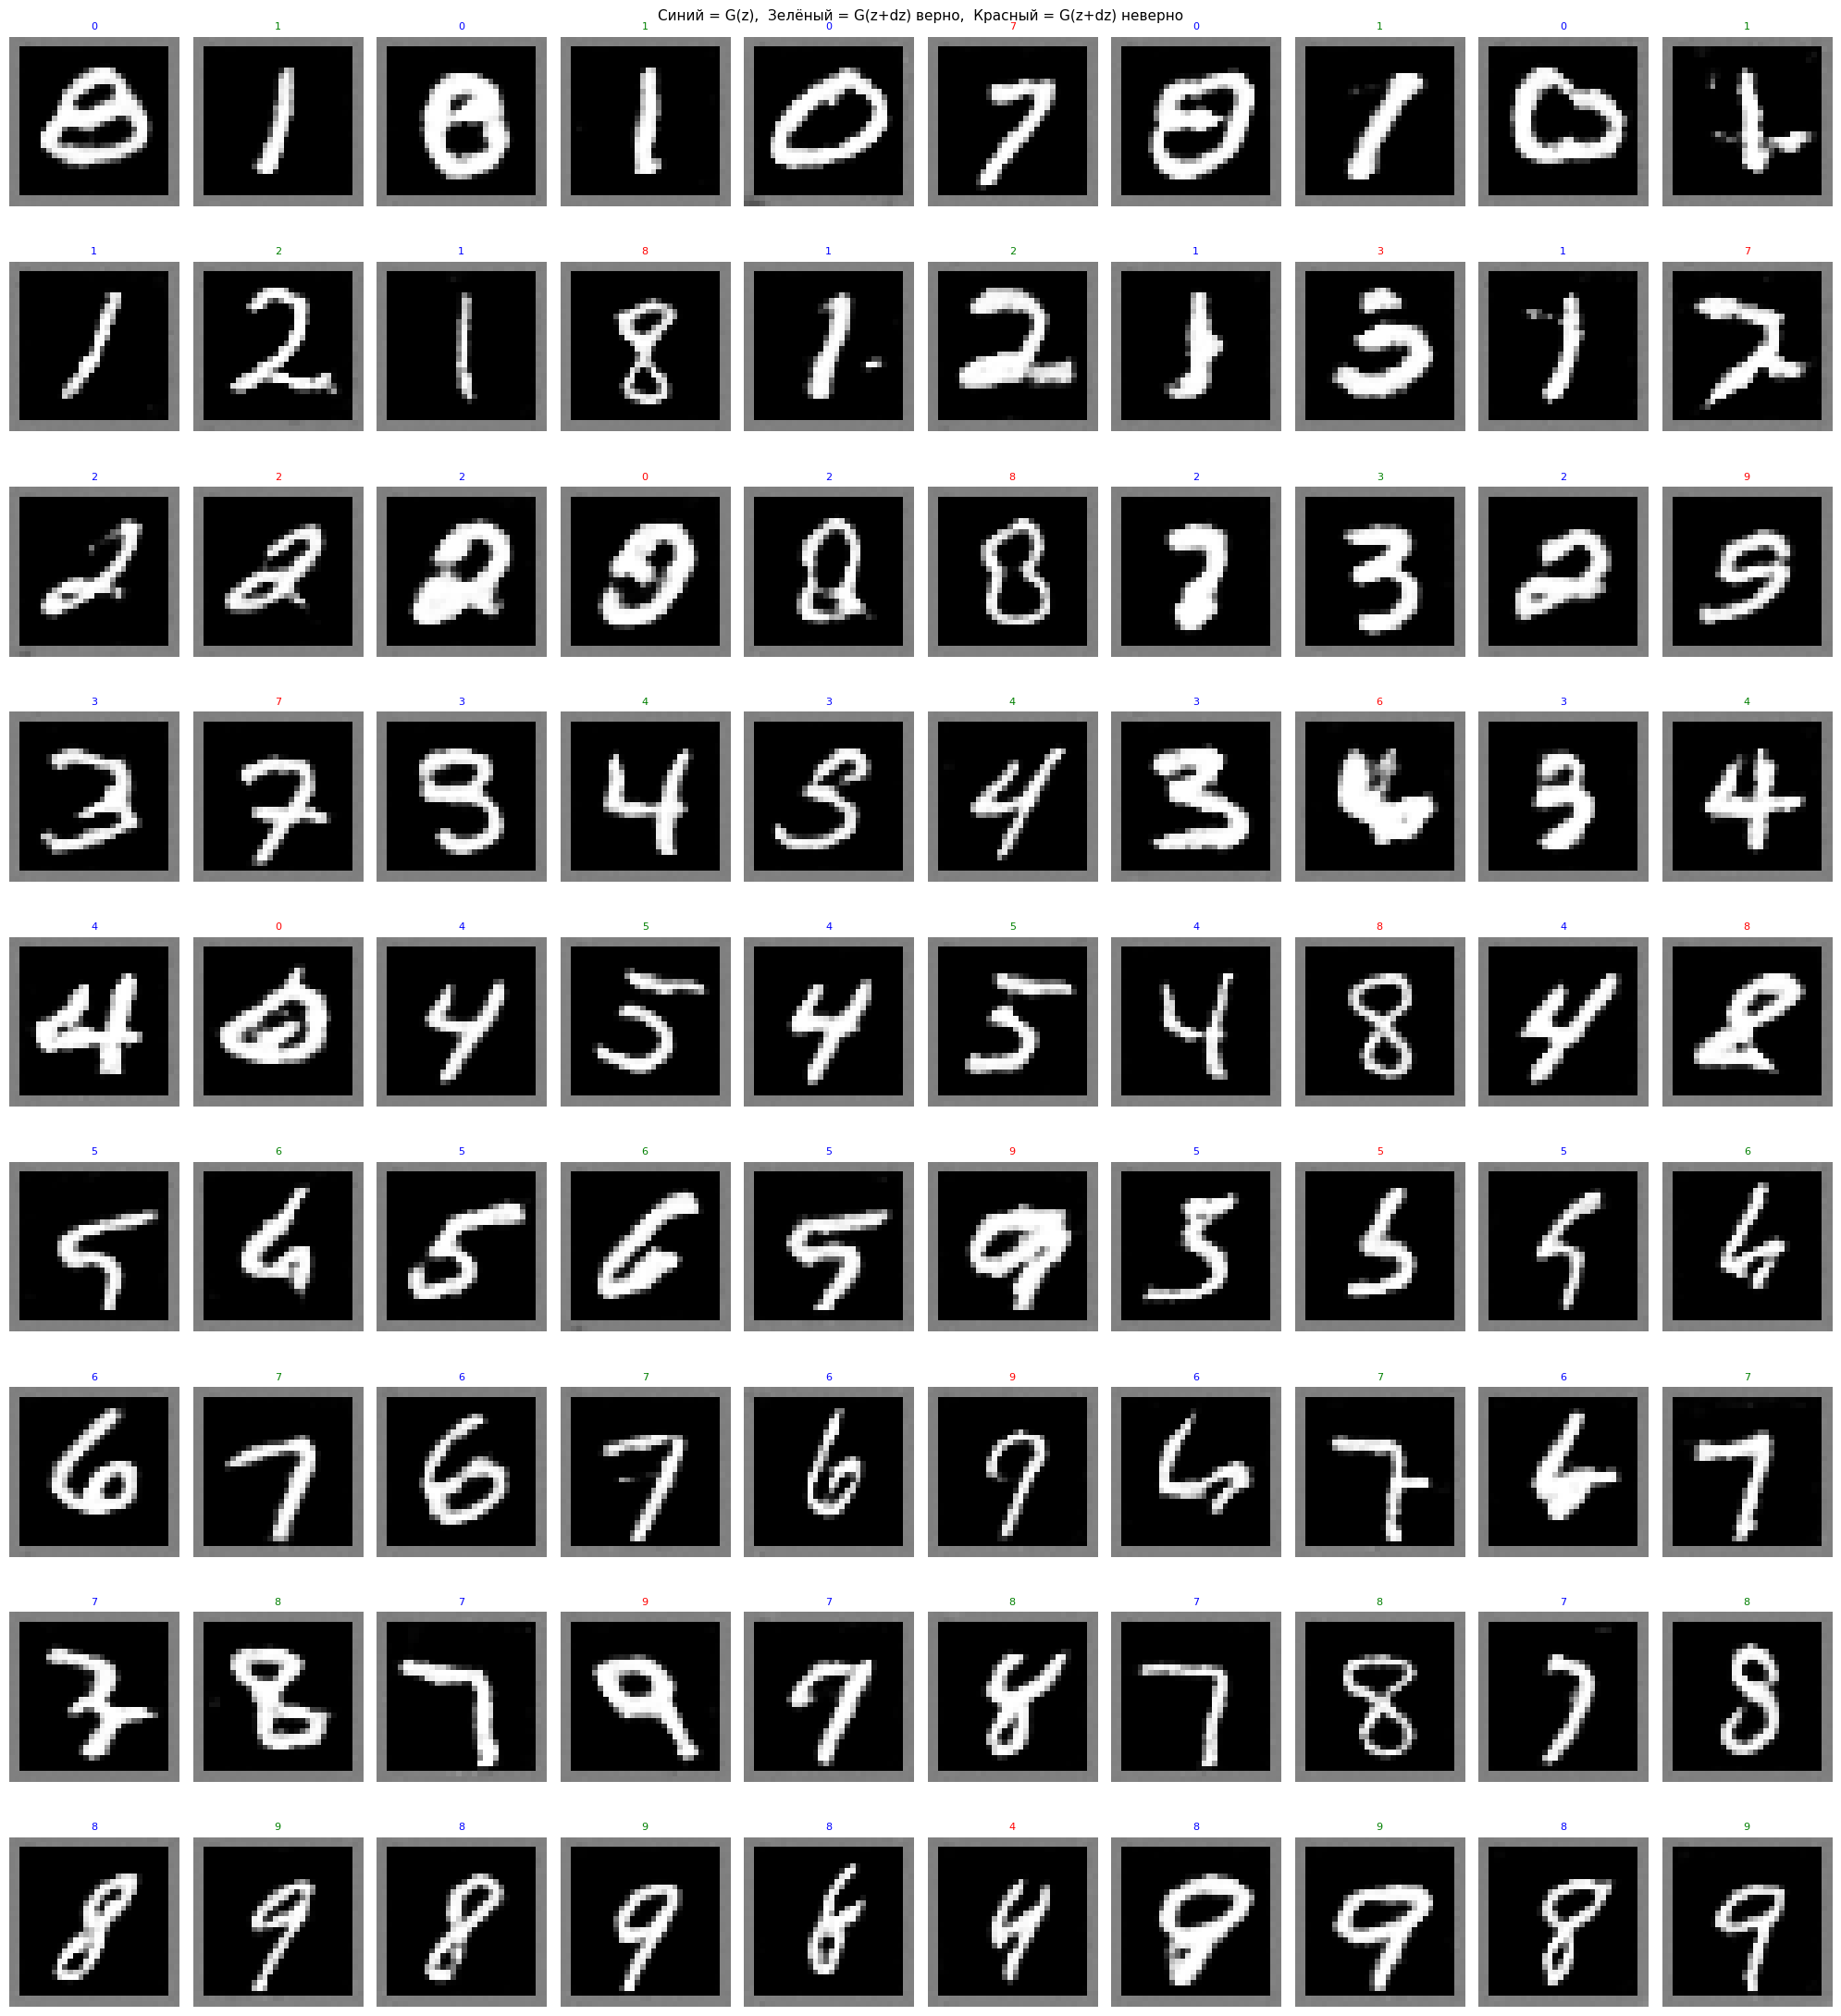

In [ ]:
generator.eval()
classifier.eval()

pairs = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),(8,9)]
n_examples = 5

fig, axes = plt.subplots(len(pairs), n_examples * 2, figsize=(n_examples * 4, len(pairs) * 2.5))

with torch.no_grad():
    for row, (n, n1) in enumerate(pairs):
        dz_pair = torch.stack(z_by_class[n1]).mean(dim=0) - torch.stack(z_by_class[n]).mean(dim=0)

        found = 0
        attempts = 0
        while found < n_examples and attempts < 2000:
            attempts += 1
            z_new       = torch.randn(1, latent_dim, device=device)
            img_orig    = generator(z_new)
            label_orig  = classifier(img_orig).argmax(dim=1).item()

            if label_orig != n:
                continue

            img_shift   = generator(z_new + dz_pair.to(device))
            label_shift = classifier(img_shift).argmax(dim=1).item()

            col_orig  = found * 2
            col_shift = found * 2 + 1

            img1 = (img_orig.cpu().squeeze().numpy()  * 0.5 + 0.5)
            img2 = (img_shift.cpu().squeeze().numpy() * 0.5 + 0.5)

            axes[row, col_orig].imshow(img1, cmap='gray')
            axes[row, col_orig].set_title(f'{label_orig}', fontsize=8, color='blue')
            axes[row, col_orig].axis('off')

            color = 'green' if label_shift == n1 else 'red'
            axes[row, col_shift].imshow(img2, cmap='gray')
            axes[row, col_shift].set_title(f'{label_shift}', fontsize=8, color=color)
            axes[row, col_shift].axis('off')

            found += 1

        axes[row, 0].set_ylabel(f'{n}→{n1}', fontsize=10, rotation=0, labelpad=30)

fig.suptitle('Синий = G(z),  Зелёный = G(z+dz) верно,  Красный = G(z+dz) неверно', fontsize=11)
plt.tight_layout()
plt.show()

# Вывод:

Латентное пространство GAN не имеет чётких кластеров, но имеет слабые смещения между классами. Вектор dz
улавливает это смещение и работает как линейное направление с некоторой вероятностью
